In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Bitcoin Market Sentiment Data & Historical Trader Data**

**Part A — Data preparation**

In [ ]:
#Bitcoin Market Sentiment data
Bitcoin_market_df = pd.read_csv('/content/drive/MyDrive/fear_greed_index.csv')
Bitcoin_market_df

## Data Viewing
Bitcoin_market_df.shape    #no. of rows & columns
Bitcoin_market_df.head(10)   #first 10 rows
Bitcoin_market_df.info()     #information about data
## Data Cleaning
Bitcoin_market_df.duplicated() #duplicates
Bitcoin_market_df.drop_duplicates()  #remove duplicates
Bitcoin_market_df.isnull()         #Null Values
Bitcoin_market_df.isnull().sum()   #Count Null val

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
#Historical Trader Data
Historical_trader_df = pd.read_csv('/content/drive/MyDrive/historical_data.csv')
Historical_trader_df


## Data Viewing
Historical_trader_df.shape    #no. of rows & columns
Historical_trader_df.head(10)   #first 10 rows
Historical_trader_df.info()     #information about data
## Data Cleaning
Historical_trader_df.duplicated() #duplicates
Historical_trader_df.drop_duplicates()  #remove duplicates
Historical_trader_df.isnull()         #Null Values
Historical_trader_df.isnull().sum()   #Count Null val

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
#2. Convert timestamps and align the datasets by date (daily level is fine).

Bitcoin_market_df['Date'] = pd.to_datetime(Bitcoin_market_df['date']).dt.date
Bitcoin_market_df

Historical_trader_df['Date'] = pd.to_datetime(Historical_trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
Historical_trader_df

Merged_data = Historical_trader_df.merge(Bitcoin_market_df[['Date','classification']], on='Date', how='left')
Merged_data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25,Greed
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25,Greed
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25,Greed
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25,Greed


In [ ]:
Merged_data['abs_start_position'] = Merged_data['Start Position'].abs()
Merged_data

print(Merged_data['abs_start_position'].describe())

count    2.112240e+05
mean     1.041463e+05
std      6.663833e+05
min      0.000000e+00
25%      1.870000e+02
50%      3.221990e+03
75%      2.506421e+04
max      3.050948e+07
Name: abs_start_position, dtype: float64


In [ ]:
#3. New Daily_data Set made

Daily_data = Merged_data.groupby(['Account', 'Date']).agg(
    Daily_pnl = ('Closed PnL', 'sum'),           # total profit/loss per day
    num_trades = ('Closed PnL', 'count'),         # count of trades per day
    win_rate = ('Closed PnL', lambda x: (x > 0).mean()),  # profitable % of trades
    avg_trade_size = ('Size USD', 'mean'),
    avg_start_position = ('abs_start_position', 'mean'),
).reset_index()


Daily_data = Daily_data.merge(Bitcoin_market_df[['Date','classification']], on='Date', how='left')
print(Daily_data.head())


                                      Account        Date  Daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1   

   num_trades  win_rate  avg_trade_size  avg_start_position classification  
0         177  0.000000     5089.718249          153.887539  Extreme Greed  
1          68  0.000000     7976.664412          495.998138  Extreme Greed  
2          40  0.000000    23734.500000          456.894920  Extreme Greed  
3          12  0.000000    28186.666667          634.747083  Extreme Greed  
4          27  0.444444    17248.148148          512.998889  Extreme Greed  


**Part B — Analysis**

1. Performance Based Comparison Between Fear Vs Greed days

In [ ]:
Daily_data['cumulative_pnl'] = Daily_data.groupby('Account')['Daily_pnl'].cumsum()

Daily_data['running_max'] = Daily_data.groupby('Account')['cumulative_pnl'].cummax()

Daily_data['Drawdown'] = Daily_data['cumulative_pnl'] - Daily_data['running_max']
Daily_data

performance_comparison = Daily_data.groupby('classification').agg(
    avg_pnl = ('Daily_pnl', 'mean'),       # avg daily profit/loss
    median_pnl = ('Daily_pnl', 'median'),  # median (less affected by outliers)
    avg_win_rate = ('win_rate', 'mean'),   # avg win rate
    min_pnl = ('Daily_pnl', 'min'),      # avg drawdown proxy (worst case scenario)
    std_pnl = ('Daily_pnl', 'std')       # volatility of PnL (higher = more risky)
)

print(performance_comparison)

print(Daily_data)


                    avg_pnl  median_pnl  avg_win_rate        min_pnl  \
classification                                                         
Extreme Fear    4619.439053  218.377399      0.329659  -77308.420095   
Extreme Greed   5161.922644  418.319862      0.386387 -132271.000000   
Fear            5328.818161  107.892532      0.364033 -108604.496278   
Greed           3318.100730  158.214922      0.343559 -358963.139984   
Neutral         3438.618818  167.551743      0.355414 -113601.020138   

                     std_pnl  
classification                
Extreme Fear    29534.839183  
Extreme Greed   27496.863832  
Fear            31659.771538  
Greed           30599.040173  
Neutral         17447.863645  
                                         Account        Date     Daily_pnl  \
0     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11      0.000000   
1     0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17      0.000000   
2     0x083384f897ee0f19899168e3b1bec365f52a

2. Traders behavior change based on sentiment

In [ ]:
Behavior_comparision = Daily_data.groupby('classification').agg(
    avg_trades=('num_trades','mean'),          # trade frequency
    avg_exposure = ('avg_start_position','mean'),  # leverage proxy
    avg_size=('avg_trade_size','mean')     # position size
)
print(Behavior_comparision)



                avg_trades  avg_exposure     avg_size
classification                                       
Extreme Fear    133.750000  59514.831791  6773.464125
Extreme Greed    76.030418  60670.343049  5371.637182
Fear             98.153968  85420.218772  8975.928546
Greed            77.628086  45410.820901  6427.866594
Neutral         100.228723  78033.221528  6963.694861


In [ ]:
# Long/short bias check karo
side_by_sentiment = Merged_data.groupby(['classification','Side']).size().unstack(fill_value=0)
side_by_sentiment['long_ratio'] = side_by_sentiment['BUY'] / (side_by_sentiment['BUY'] + side_by_sentiment['SELL'])
print(side_by_sentiment)


Side              BUY   SELL  long_ratio
classification                          
Extreme Fear    10935  10465    0.510981
Extreme Greed   17940  22052    0.448590
Fear            30270  31567    0.489513
Greed           24576  25727    0.488559
Neutral         18969  18717    0.503343


3.  High vs Low leverage traders





In [ ]:
median_lev = Daily_data['avg_start_position'].median()
Daily_data['leverage_segment'] = np.where(Daily_data['avg_start_position'] > median_lev, 'High leverage', 'Low leverage')

Daily_data

,Account,Date,Daily_pnl,num_trades,win_rate,avg_trade_size,avg_start_position,classification,cumulative_pnl,running_max,Drawdown,leverage_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,153.887539,Extreme Greed,0.000000,0.000000,0.0,Low leverage
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,68,0.000000,7976.664412,495.998138,Extreme Greed,0.000000,0.000000,0.0,Low leverage
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,40,0.000000,23734.500000,456.894920,Extreme Greed,0.000000,0.000000,0.0,Low leverage
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,12,0.000000,28186.666667,634.747083,Extreme Greed,-21227.000000,0.000000,-21227.0,Low leverage
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,27,0.444444,17248.148148,512.998889,Extreme Greed,-19623.900000,0.000000,-19623.9,Low leverage
...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,82,0.390244,2153.859390,3840.289024,Greed,819625.395990,819625.395990,0.0,High leverage
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,430,0.393023,1495.538419,3179.932911,Neutral,823633.984898,823633.984898,0.0,High leverage
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,902,0.441242,1939.739989,5238.831264,Greed,832195.756736,832195.756736,0.0,High leverage
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,75,0.520000,1748.805333,790.559550,Greed,834716.530550,834716.530550,0.0,Low leverage


# Frequent vs Infrequent traders





In [ ]:
median_trades = Daily_data['num_trades'].median()
Daily_data['frequency_segment'] = np.where(Daily_data['num_trades'] > median_trades, 'Frequent', 'Infrequent')

Daily_data

,Account,Date,Daily_pnl,num_trades,win_rate,avg_trade_size,avg_start_position,classification,cumulative_pnl,running_max,Drawdown,leverage_segment,frequency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,153.887539,Extreme Greed,0.000000,0.000000,0.0,Low leverage,Frequent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,68,0.000000,7976.664412,495.998138,Extreme Greed,0.000000,0.000000,0.0,Low leverage,Frequent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,40,0.000000,23734.500000,456.894920,Extreme Greed,0.000000,0.000000,0.0,Low leverage,Frequent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,12,0.000000,28186.666667,634.747083,Extreme Greed,-21227.000000,0.000000,-21227.0,Low leverage,Infrequent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,27,0.444444,17248.148148,512.998889,Extreme Greed,-19623.900000,0.000000,-19623.9,Low leverage,Infrequent
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,82,0.390244,2153.859390,3840.289024,Greed,819625.395990,819625.395990,0.0,High leverage,Frequent
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,430,0.393023,1495.538419,3179.932911,Neutral,823633.984898,823633.984898,0.0,High leverage,Frequent
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,902,0.441242,1939.739989,5238.831264,Greed,832195.756736,832195.756736,0.0,High leverage,Frequent
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,75,0.520000,1748.805333,790.559550,Greed,834716.530550,834716.530550,0.0,Low leverage,Frequent


consistent winners vs inconsistent traders

In [ ]:
Trader_consistency = Daily_data.groupby('Account')['win_rate'].std().reset_index()
# std() = fluctuation of win rate for diff account across different days
Trader_consistency.columns = ['Account','win_rate_std']

Trader_consistency

median_std = Trader_consistency['win_rate_std'].median()
Trader_consistency['consistency_segment'] = np.where(
    Trader_consistency['win_rate_std'] < median_std, 'Consistent', 'Inconsistent'
)
# Low std = win rate stableb = Consistent
# High std = win rate fluctuate = Inconsistent

Daily_data = Daily_data.merge(Trader_consistency[['Account','consistency_segment']], on='Account', how='left')
Daily_data

,Account,Date,Daily_pnl,num_trades,win_rate,avg_trade_size,avg_start_position,classification,cumulative_pnl,running_max,Drawdown,leverage_segment,frequency_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,153.887539,Extreme Greed,0.000000,0.000000,0.0,Low leverage,Frequent,Consistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,68,0.000000,7976.664412,495.998138,Extreme Greed,0.000000,0.000000,0.0,Low leverage,Frequent,Consistent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,40,0.000000,23734.500000,456.894920,Extreme Greed,0.000000,0.000000,0.0,Low leverage,Frequent,Consistent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,12,0.000000,28186.666667,634.747083,Extreme Greed,-21227.000000,0.000000,-21227.0,Low leverage,Infrequent,Consistent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,27,0.444444,17248.148148,512.998889,Extreme Greed,-19623.900000,0.000000,-19623.9,Low leverage,Infrequent,Consistent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807,82,0.390244,2153.859390,3840.289024,Greed,819625.395990,819625.395990,0.0,High leverage,Frequent,Consistent
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908,430,0.393023,1495.538419,3179.932911,Neutral,823633.984898,823633.984898,0.0,High leverage,Frequent,Consistent
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838,902,0.441242,1939.739989,5238.831264,Greed,832195.756736,832195.756736,0.0,High leverage,Frequent,Consistent
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814,75,0.520000,1748.805333,790.559550,Greed,834716.530550,834716.530550,0.0,Low leverage,Frequent,Consistent


In [ ]:
display(Daily_data.head())

,Account,Date,Daily_pnl,num_trades,win_rate,avg_trade_size,avg_start_position,classification,cumulative_pnl,running_max,Drawdown,leverage_segment,frequency_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0.000000,5089.718249,153.887539,Extreme Greed,0.0,0.0,0.0,Low leverage,Frequent,Consistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0.000000,7976.664412,495.998138,Extreme Greed,0.0,0.0,0.0,Low leverage,Frequent,Consistent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0.000000,23734.500000,456.894920,Extreme Greed,0.0,0.0,0.0,Low leverage,Frequent,Consistent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,0.000000,28186.666667,634.747083,Extreme Greed,-21227.0,0.0,-21227.0,Low leverage,Infrequent,Consistent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,0.444444,17248.148148,512.998889,Extreme Greed,-19623.9,0.0,-19623.9,Low leverage,Infrequent,Consistent


In [ ]:
seg1 = Daily_data.groupby(['leverage_segment','classification'])['Daily_pnl'].mean().unstack()
print("Segment 1 - Leverage:\n", seg1)


seg2 = Daily_data.groupby(['frequency_segment','classification'])['Daily_pnl'].mean().unstack()
print("Segment 2 - Frequency:\n", seg2)


seg3 = Daily_data.groupby(['consistency_segment','classification'])['Daily_pnl'].mean().unstack()
print("Segment 3 - Consistency:\n", seg3)

Segment 1 - Leverage:
 classification    Extreme Fear  Extreme Greed        Fear        Greed  \
leverage_segment                                                         
High leverage      5068.883866    9369.474378  5185.70614  4813.549300   
Low leverage       4122.684260     481.232562  5471.02441  1885.903761   

classification        Neutral  
leverage_segment               
High leverage     5285.811377  
Low leverage      1795.638502  
Segment 2 - Frequency:
 classification     Extreme Fear  Extreme Greed          Fear        Greed  \
frequency_segment                                                           
Frequent            6799.753651    8437.437459  10311.492505  5486.377107   
Infrequent           457.020275    1627.473851    913.034911  1401.949513   

classification         Neutral  
frequency_segment               
Frequent           5759.162182  
Infrequent         1118.075454  
Segment 3 - Consistency:
 classification       Extreme Fear  Extreme Greed         Fear

**Fear days outperform Greed days (Counterintuitive finding)**

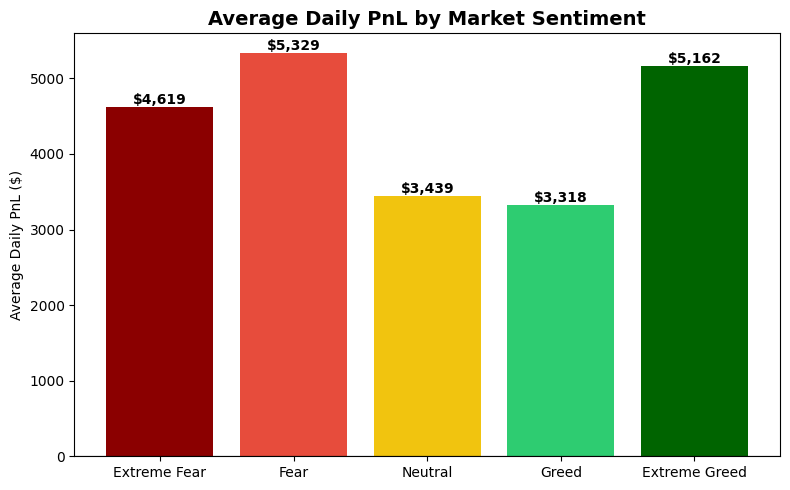

In [ ]:
import matplotlib.pyplot as plt

sentiment_colors = {
    'Extreme Fear': '#8B0000', 'Fear': '#E74C3C',
    'Neutral': '#F1C40F', 'Greed': '#2ECC71', 'Extreme Greed': '#006400'
}

comparison = Daily_data.groupby('classification')['Daily_pnl'].mean().reindex(
    ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(comparison.index, comparison.values,
               color=[sentiment_colors[x] for x in comparison.index])
ax.set_title('Average Daily PnL by Market Sentiment', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Daily PnL ($)')
ax.axhline(0, color='black', linewidth=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, height, f'${height:,.0f}',
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('insight1_pnl_by_sentiment.png', dpi=150)
plt.show()










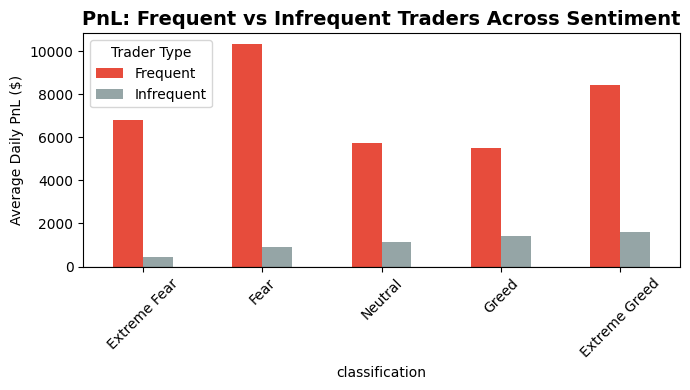

In [ ]:
seg2 = Daily_data.groupby(['frequency_segment', 'classification'])['Daily_pnl'].mean().unstack()
seg2 = seg2[['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']]  # order fix

fig, ax = plt.subplots(figsize=(7,4))
seg2.T.plot(kind='bar', ax=ax, color=['#E74C3C','#95A5A6'])
ax.set_title('PnL: Frequent vs Infrequent Traders Across Sentiment', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Daily PnL ($)')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title='Trader Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('insight2_frequency_segment.png', dpi=150)

plt.show()










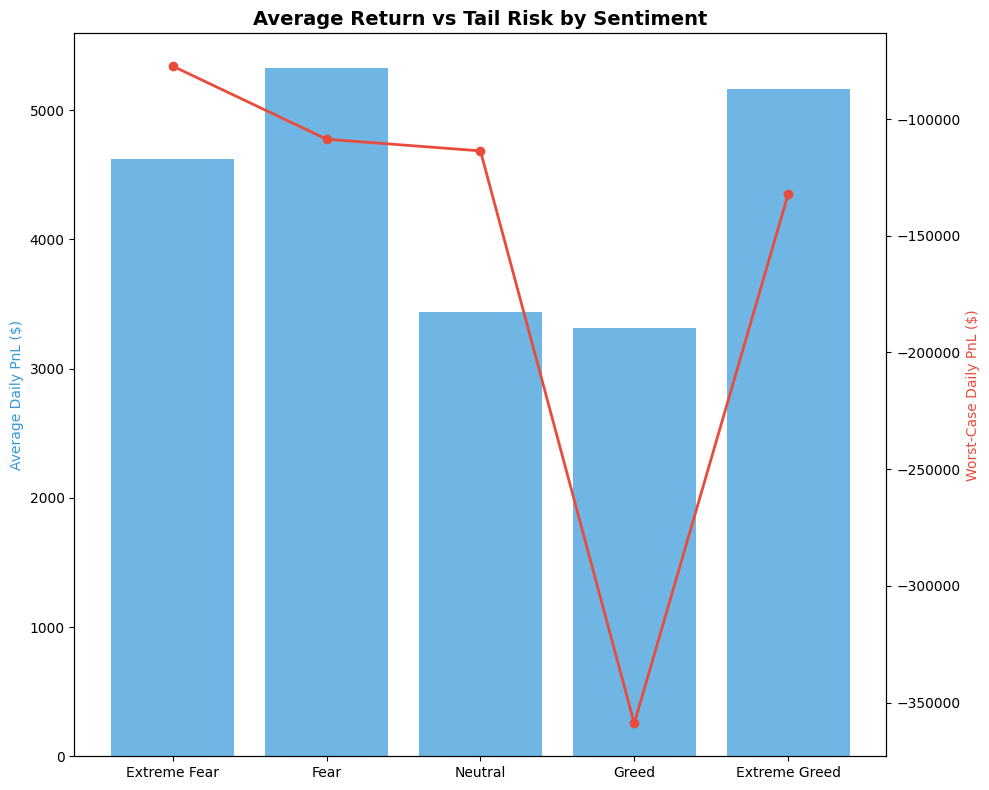

In [ ]:
risk_comparison = Daily_data.groupby('classification')['Daily_pnl'].agg(['mean','min','std']).reindex(
    ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
)

fig, ax = plt.subplots(figsize=(10,8))
ax2 = ax.twinx()  # dusra y-axis, kyunki mean aur min ki scale bahut alag hai

ax.bar(risk_comparison.index, risk_comparison['mean'], color='#3498DB', alpha=0.7, label='Avg PnL')
ax2.plot(risk_comparison.index, risk_comparison['min'], color='#E74C3C', marker='o',
          linewidth=2, label='Worst Case (Min PnL)')

ax.set_ylabel('Average Daily PnL ($)', color='#3498DB')
ax2.set_ylabel('Worst-Case Daily PnL ($)', color='#E74C3C')
ax.set_title('Average Return vs Tail Risk by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('insight3_tail_risk.png', dpi=150)

plt.show()


# **Actionable Strategy Recommendations**
Strategy 1: Don't reduce trading activity during Fear —
infrequent trading is the real risk
*   Frequent traders earned 5-10x more than infrequent
traders in every sentiment condition
(e.g., \$10,311 vs \$913 during Fear days.)
*   Rule: Traders should keep trading normally during
Fear days instead of pulling back. Staying inactive
hurts performance more than the market sentiment
itself does.
*   Why: More trading activity likely means better
strategy execution and faster reaction to
opportunities
— this matters more than what the overall
market "mood" is.







Strategy 2: Set a hard position-size limit during Greed days
*   Finding: Greed days looked safe on average
  (\$3,318 avg PnL), but had the worst
  single-day loss of all categories (-\$358,963)
  — far worse than any Fear period.
*  Rule: Apply a strict cap on position size
during Greed/Extreme Greed, even though
average returns look fine. Don't let good
"average" numbers create false confidence.
* Why: Averages hide risk. A few overconfident
traders taking oversized bets during Greed
periods can cause catastrophic losses that
don't show up until you check the worst-case
numbers.
